# Model Comparison — CZM Surrogate ANN

Compares all trained models against the professor's reported baseline (Val MSE = 3.83×10⁻⁵):
- **Track A** `baseline` — exact replication of professor's 160→256→128→128→64→32→1 ANN
- **Track B** `enhanced` — wider ANN with delta features + inverse-frequency sample weights
- **Track B R2** `enhanced_r2` — Enhanced ANN with transition-zone weighted loss (3×) + val_mse EarlyStopping fix **(current best)**
- **Track C** `lstm` / `lstm_r3` / `lstm_r4` / `lstm_r5` — LSTM variants

**Run training scripts first:**
```bash
python scripts/train_model.py --model baseline
python scripts/train_model.py --model enhanced
python scripts/train_model.py --model enhanced_r2
python scripts/train_model.py --model lstm_r4
```

Missing model weights are handled gracefully — plots skip unavailable models.

In [11]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Project root is one level above notebooks/
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import tensorflow as tf
from tensorflow import keras
from pipeline import config
from models import baseline_ann, enhanced_ann, enhanced_ann_r2, lstm_model
from models.lstm_model import (
    build_lstm_model_r3,
    build_lstm_model_r4,
    build_lstm_model_r5,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Colour palette — consistent across all plots
BIN_COLORS = {
    'initiation': '#2196F3',
    'transition':  '#FF9800',
    'post_peak':   '#4CAF50',
    'failed':      '#E53935',
}
MODEL_COLORS = {
    'true':          'black',
    'baseline':      '#C62828',
    'enhanced':      '#1565C0',
    'enhanced_r2':   '#0D47A1',
    'lstm':          '#2E7D32',
    'lstm_r3':       '#00897B',
    'lstm_r4':       '#7B1FA2',
    'lstm_r5':       '#F57F17',
}
MODEL_LABELS = {
    'baseline':      'Baseline ANN (professor)',
    'enhanced':      'Enhanced ANN (Track B)',
    'enhanced_r2':   'Enhanced ANN R2 (transition loss)',
    'lstm':          'LSTM Round 2 (Track C)',
    'lstm_r3':       'LSTM Round 3 (feat. select)',
    'lstm_r4':       'LSTM Round 4 (BiLSTM+attn)',
    'lstm_r5':       'LSTM Round 5 (Huber loss)',
}
PROFESSOR_VAL_MSE = 3.83e-5
print('Setup complete. TF version:', tf.__version__)

Setup complete. TF version: 2.21.0


## 1. Load Data

In [12]:
PROCESSED_DIR = os.path.join(ROOT, 'data', 'processed')
SAVE_DIR      = os.path.join(ROOT, 'models', 'saved')

test  = np.load(os.path.join(PROCESSED_DIR, 'test.npz'))
val   = np.load(os.path.join(PROCESSED_DIR, 'val.npz'))

X_test, y_test = test['X'].astype('float32'), test['y'].astype('float32')
X_val,  y_val  = val['X'].astype('float32'),  val['y'].astype('float32')

# Scaler for unscaling separN back to physical units
with open(os.path.join(PROCESSED_DIR, 'scaler.json')) as f:
    scaler_data = json.load(f)
scaler_mean  = np.array(scaler_data['mean'],  dtype='float32')   # shape (160,)
scaler_scale = np.array(scaler_data['scale'], dtype='float32')   # shape (160,)

# h0_separN is flat index 2 in the 160-feature vector.
# After temporal reversal in the pipeline, h0 (most recent) is at
# temporal axis index 19. So X[:, 19, 2] = scaled h0_separN.
SEP_N_FLAT_IDX = 2   # position of separN in the 160-feature flat vector

def unscale_sep_n(X_temporal):
    """Unscale the most-recent separN from (N,20,16) tensor."""
    scaled = X_temporal[:, 19, 2]          # newest timestep, separN feature
    return scaled * scaler_scale[SEP_N_FLAT_IDX] + scaler_mean[SEP_N_FLAT_IDX]

sep_n_test = unscale_sep_n(X_test)        # physical separN (mm) for test set

# Bin assignment for colouring
interior = np.array(config.D_BIN_EDGES[1:-1], dtype='float32')
bin_idx_test = np.searchsorted(interior, y_test, side='right')
bin_idx_test = np.clip(bin_idx_test, 0, len(config.D_BIN_LABELS)-1)

print(f'Test  set: {X_test.shape}, y ∈ [{y_test.min():.3f}, {y_test.max():.3f}]')
print(f'Val   set: {X_val.shape}')
print(f'separN test range: [{sep_n_test.min():.5f}, {sep_n_test.max():.5f}] mm')

Test  set: (7000, 20, 16), y ∈ [0.000, 1.000]
Val   set: (7001, 20, 16)
separN test range: [0.00008, 0.08259] mm


## 2. Load Models & Generate Predictions

In [13]:
def try_load(name, build_fn, prepare_fn):
    """Load saved weights into a freshly built model. Returns (model, y_pred) or (None, None)."""
    weights_path = os.path.join(SAVE_DIR, name, 'best_model.weights.h5')
    if not os.path.exists(weights_path):
        print(f'[{name}] No weights found — skipping.')
        return None, None
    model = build_fn()
    model.load_weights(weights_path)
    X_in   = prepare_fn(X_test)
    y_pred = model.predict(X_in, verbose=0).flatten()
    mse    = float(np.mean((y_pred - y_test)**2))
    print(f'[{name}]  Test MSE: {mse:.4e}  | vs professor: {mse/PROFESSOR_VAL_MSE:.2f}×')
    return model, y_pred

models, preds = {}, {}

for name, build_fn, prepare_fn in [
    ('baseline',     baseline_ann.build_baseline_ann,          baseline_ann.prepare_inputs),
    ('enhanced',     enhanced_ann.build_enhanced_ann,          enhanced_ann.prepare_inputs),
    ('enhanced_r2',  enhanced_ann_r2.build_enhanced_ann_r2,    enhanced_ann_r2.prepare_inputs),
    ('lstm',         lstm_model.build_lstm_model,              lstm_model.prepare_inputs),
    ('lstm_r3',      build_lstm_model_r3,                      lstm_model.prepare_inputs),
    ('lstm_r4',      build_lstm_model_r4,                      lstm_model.prepare_inputs),
    ('lstm_r5',      build_lstm_model_r5,                      lstm_model.prepare_inputs),
]:
    m, p = try_load(name, build_fn, prepare_fn)
    if m:
        models[name], preds[name] = m, p

available = list(preds.keys())
print(f'\nModels available for plotting: {available}')

c:\Users\Jay Leung\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[baseline]  Test MSE: 3.4554e-05  | vs professor: 0.90×


c:\Users\Jay Leung\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[enhanced]  Test MSE: 3.6358e-05  | vs professor: 0.95×
[enhanced_r2]  Test MSE: 2.0588e-05  | vs professor: 0.54×


c:\Users\Jay Leung\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[lstm]  Test MSE: 5.2610e-05  | vs professor: 1.37×
[lstm_r3]  Test MSE: 4.7627e-05  | vs professor: 1.24×


c:\Users\Jay Leung\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[lstm_r4]  Test MSE: 3.6336e-05  | vs professor: 0.95×
[lstm_r5]  Test MSE: 6.1005e-05  | vs professor: 1.59×

Models available for plotting: ['baseline', 'enhanced', 'enhanced_r2', 'lstm', 'lstm_r3', 'lstm_r4', 'lstm_r5']


## Plot 1 — Training Curves

Val loss vs epoch on a log scale. The horizontal dashed line marks the professor's reported Val MSE = 3.83×10⁻⁵.
Any model whose final val_loss falls below the dashed line outperforms the professor's baseline.

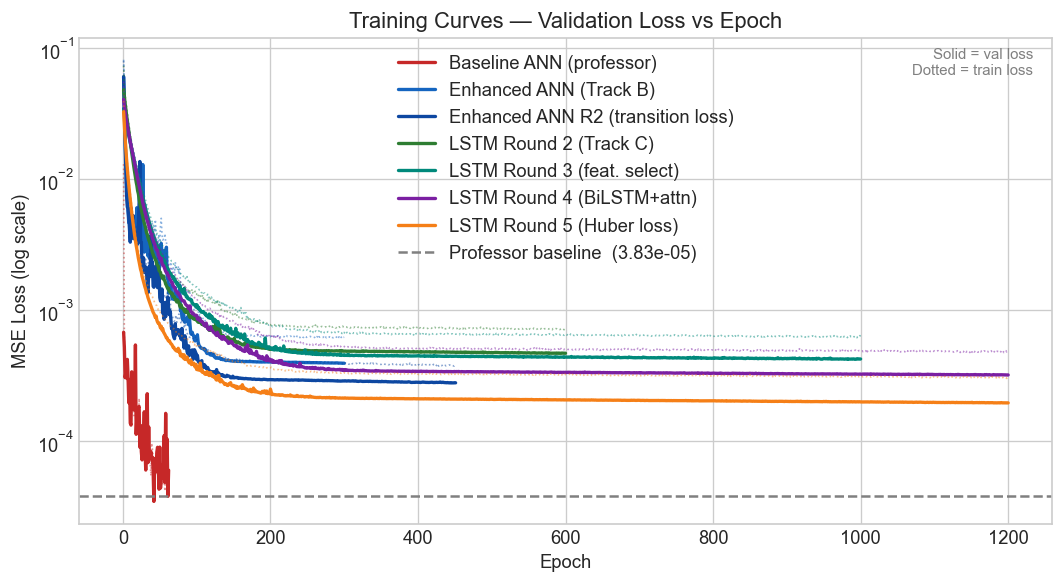

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for name in available:
    log_path = os.path.join(SAVE_DIR, name, 'train.log')
    if not os.path.exists(log_path):
        continue
    df_log = pd.read_csv(log_path)
    ax.plot(df_log['epoch'] + 1, df_log['val_loss'],
            color=MODEL_COLORS[name], lw=2, label=MODEL_LABELS[name])
    # Also plot train loss as dotted line
    ax.plot(df_log['epoch'] + 1, df_log['loss'],
            color=MODEL_COLORS[name], lw=1, ls=':', alpha=0.5)

ax.axhline(PROFESSOR_VAL_MSE, color='gray', ls='--', lw=1.5,
           label=f"Professor baseline  ({PROFESSOR_VAL_MSE:.2e})")

ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (log scale)')
ax.set_title('Training Curves — Validation Loss vs Epoch')
ax.legend(framealpha=0.9)
ax.annotate('Solid = val loss\nDotted = train loss', xy=(0.98, 0.98),
            xycoords='axes fraction', ha='right', va='top',
            fontsize=9, color='gray')
plt.tight_layout()
plt.show()

## Plot 2 — D_pred vs D_true Scatter

One panel per model. Points coloured by damage bin:
- Blue = initiation (D < 0.3)
- Orange = **transition** (0.3 ≤ D < 0.7) — the physically critical zone
- Green = post-peak (0.7 ≤ D < 0.9)
- Red = failed (D ≥ 0.9)

The diagonal (black dashed) = perfect prediction. Orange scatter far from the diagonal = the source of the Load-Crack Opening split in slide 9.

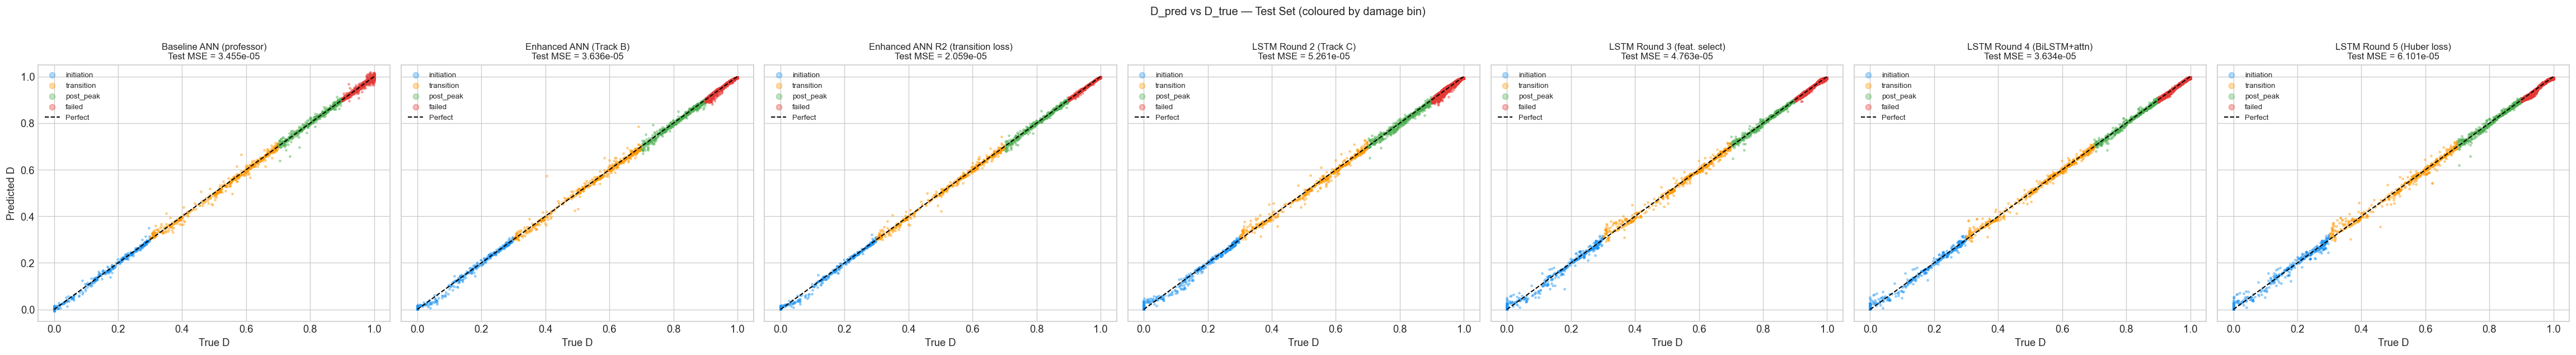

In [15]:
n_models = len(available)
if n_models == 0:
    print('No models loaded — train at least one model first.')
else:
    fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 5.2), sharey=True)
    if n_models == 1:
        axes = [axes]

    for ax, name in zip(axes, available):
        y_pred = preds[name]
        for i, label in enumerate(config.D_BIN_LABELS):
            mask = bin_idx_test == i
            ax.scatter(y_test[mask], y_pred[mask],
                       c=BIN_COLORS[label], s=4, alpha=0.35, label=label,
                       rasterized=True)
        ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect')
        mse = float(np.mean((y_pred - y_test)**2))
        ax.set_title(f'{MODEL_LABELS[name]}\nTest MSE = {mse:.3e}', fontsize=10)
        ax.set_xlabel('True D')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        if ax is axes[0]:
            ax.set_ylabel('Predicted D')
        ax.legend(markerscale=3, fontsize=8, loc='upper left')

    fig.suptitle('D_pred vs D_true — Test Set (coloured by damage bin)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

## Plot 3 — Stratified MAE by Damage Bin

Lower bars = better. The **transition** bin (orange) is the key comparison:
this is where prediction errors directly cause peak-load overestimation in FEA.

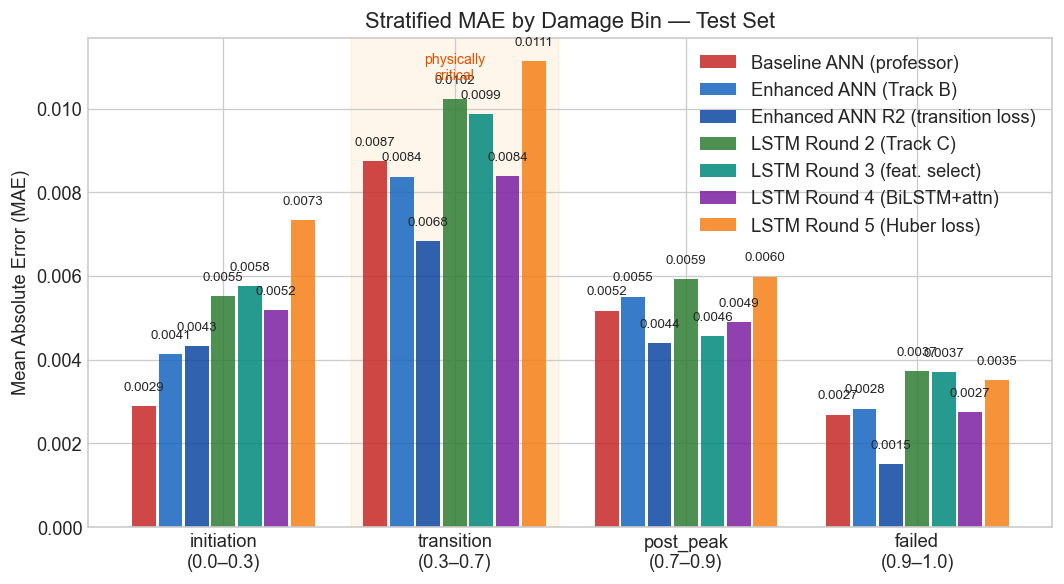

In [16]:
def stratified_mae(y_true, y_pred):
    """Return dict {bin_label: mae} for each damage bin."""
    idx = np.searchsorted(interior, y_true, side='right')
    idx = np.clip(idx, 0, len(config.D_BIN_LABELS)-1)
    result = {}
    for i, label in enumerate(config.D_BIN_LABELS):
        mask = idx == i
        result[label] = float(np.mean(np.abs(y_pred[mask] - y_true[mask]))) if mask.sum() else np.nan
    return result

mae_table = {name: stratified_mae(y_test, preds[name]) for name in available}

bins  = config.D_BIN_LABELS
x     = np.arange(len(bins))
width = 0.8 / max(len(available), 1)

fig, ax = plt.subplots(figsize=(9, 5))
for k, name in enumerate(available):
    offsets = x + (k - (len(available)-1)/2) * width
    vals    = [mae_table[name][b] for b in bins]
    bars    = ax.bar(offsets, vals, width=width * 0.9,
                     color=MODEL_COLORS[name], label=MODEL_LABELS[name], alpha=0.85)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.0003,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'{b}\n({config.D_BIN_EDGES[i]:.1f}–{config.D_BIN_EDGES[i+1]:.1f})'
                    for i, b in enumerate(bins)])
ax.set_ylabel('Mean Absolute Error (MAE)')
ax.set_title('Stratified MAE by Damage Bin — Test Set')
ax.legend()

# Highlight the transition bin
ax.axvspan(x[1]-0.45, x[1]+0.45, color='#FF9800', alpha=0.08, zorder=0,
           label='_transition highlight')
ax.text(x[1], ax.get_ylim()[1]*0.97, 'physically\ncritical',
        ha='center', va='top', fontsize=8.5, color='#E65100')

plt.tight_layout()
plt.show()

## Plot 4 — Error Distribution per Bin (Violin Plot)

Shows the full distribution of |y_pred − y_true|, not just the mean. Fat tails in the transition bin explain outlier FEA steps that cause the Load–Crack Opening curve to split.

c:\Users\Jay Leung\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\Jay Leung\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\Jay Leung\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\Jay Leung\AppData\Local\Programs\P

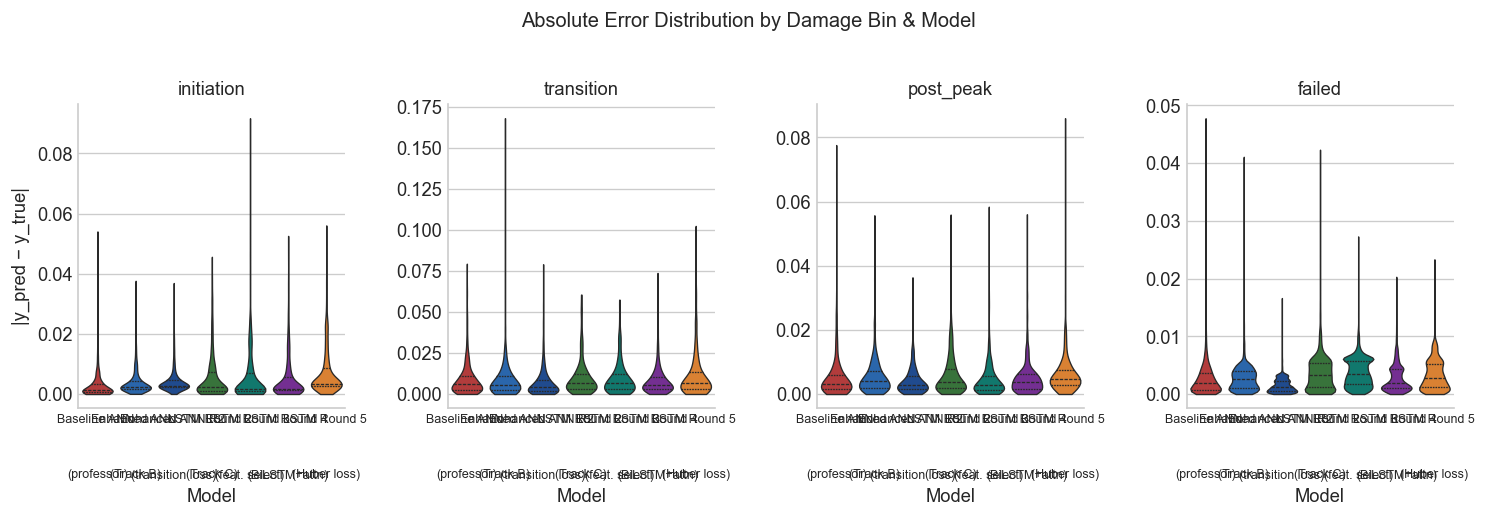

In [17]:
records = []
for name in available:
    y_pred = preds[name]
    abs_err = np.abs(y_pred - y_test)
    for i, label in enumerate(config.D_BIN_LABELS):
        mask = bin_idx_test == i
        for e in abs_err[mask]:
            records.append({'model': MODEL_LABELS[name], 'bin': label, 'abs_error': e})

df_err = pd.DataFrame(records)

if df_err.empty:
    print('No predictions to plot.')
else:
    g = sns.FacetGrid(df_err, col='bin', col_order=config.D_BIN_LABELS,
                      height=4.2, aspect=0.75, sharey=False)
    palette = {MODEL_LABELS[n]: MODEL_COLORS[n] for n in available}
    g.map_dataframe(sns.violinplot, x='model', y='abs_error',
                    palette=palette, inner='quartile', linewidth=0.8, cut=0)
    g.set_titles(col_template='{col_name}')
    g.set_axis_labels('Model', '|y_pred − y_true|')
    for ax in g.axes.flat:
        ax.set_xticklabels([l.get_text().replace('(', '\n(') for l in ax.get_xticklabels()],
                           fontsize=7.5)
    g.figure.suptitle('Absolute Error Distribution by Damage Bin & Model', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

## Plot 5 — Damage Trajectory (Slide 9 Analog)

The professor's slide 9 shows **Force vs Crack Opening** from a full FEA simulation — we cannot reproduce that without running Abaqus. This plot is the closest Python-side equivalent:

- **X-axis**: physical normal separation (separN, mm) of the most-recent history step, sorted ascending → proxy for crack opening progression
- **Y-axis**: damage D
- **Lines**: rolling mean of true D and each model's predicted D, binned by separN

If a model's orange line (transition zone, separN ≈ 0.005–0.05 mm) closely follows the black 'true' line, peak-load overestimation in FEA will be reduced. The professor's baseline is expected to deviate there — that is the "split" from slide 9.

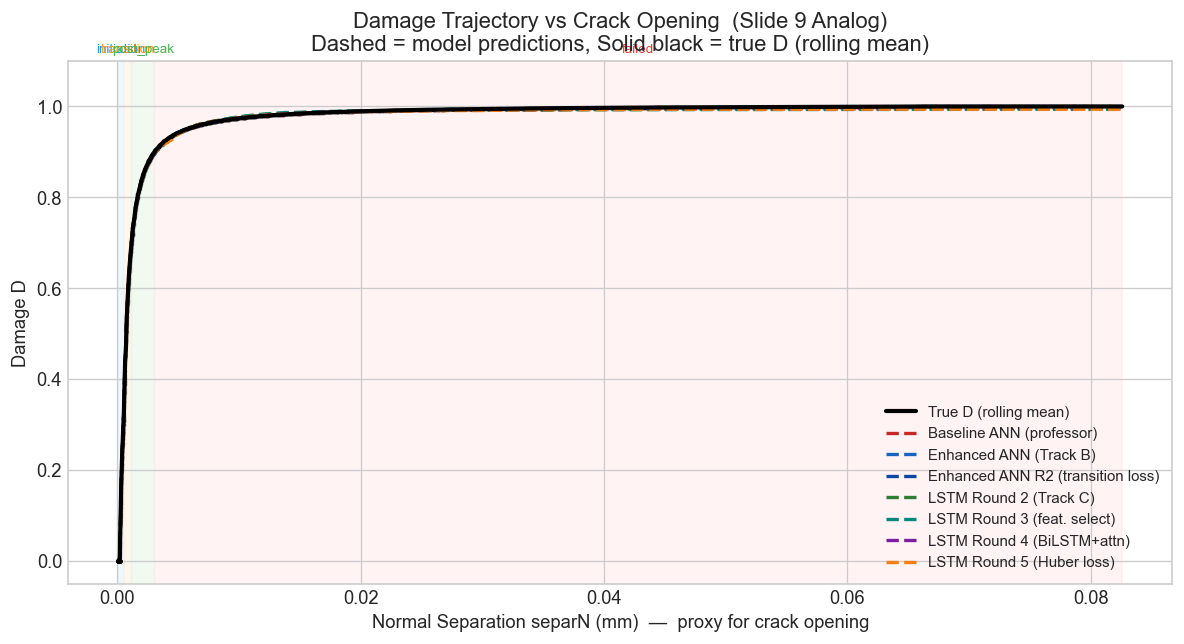


Interpretation:
  • In the TRANSITION region (orange shade), a model whose dashed line
    closely follows the solid black line will produce accurate traction values,
    preventing peak-load overestimation in the FEA embedding.
  • Deviation from the true D in the transition zone = the slide-9 split.


In [18]:
if not available:
    print('No models loaded.')
else:
    # Sort ALL test samples by their most-recent separN (physical units)
    sort_idx   = np.argsort(sep_n_test)
    sep_sorted = sep_n_test[sort_idx]
    y_sorted   = y_test[sort_idx]
    bins_sorted = bin_idx_test[sort_idx]

    # Rolling mean with a window of 150 samples to create a smooth trajectory
    def rolling_mean(arr, window=150):
        return pd.Series(arr).rolling(window, min_periods=1, center=True).mean().values

    fig, ax = plt.subplots(figsize=(10, 5.5))

    # Shade regions by damage bin
    bin_cmap = {'initiation': '#E3F2FD', 'transition': '#FFF3E0',
                'post_peak': '#E8F5E9', 'failed': '#FFEBEE'}
    prev_x = sep_sorted[0]
    for i, label in enumerate(config.D_BIN_LABELS):
        mask_b = bins_sorted == i
        if mask_b.sum() > 0:
            x0 = sep_sorted[mask_b].min()
            x1 = sep_sorted[mask_b].max()
            ax.axvspan(x0, x1, color=bin_cmap[label], alpha=0.6, zorder=0)
            ax.text((x0+x1)/2, 1.01, label, ha='center', va='bottom',
                    fontsize=8, color=list(BIN_COLORS.values())[i],
                    transform=ax.get_xaxis_transform(), clip_on=False)

    # True D — scatter + rolling mean
    ax.scatter(sep_sorted, y_sorted, c='black', s=1.5, alpha=0.08, rasterized=True, zorder=1)
    ax.plot(sep_sorted, rolling_mean(y_sorted), color=MODEL_COLORS['true'],
            lw=2.5, label='True D (rolling mean)', zorder=5)

    # Each model's predictions
    for name in available:
        y_pred_sorted = preds[name][sort_idx]
        ax.plot(sep_sorted, rolling_mean(y_pred_sorted),
                color=MODEL_COLORS[name], lw=2, ls='--',
                label=MODEL_LABELS[name], zorder=4)

    ax.set_xlabel('Normal Separation separN (mm)  —  proxy for crack opening')
    ax.set_ylabel('Damage D')
    ax.set_title('Damage Trajectory vs Crack Opening  (Slide 9 Analog)\n'
                 'Dashed = model predictions, Solid black = true D (rolling mean)')
    ax.set_ylim(-0.05, 1.10)
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

    print()
    print('Interpretation:')
    print('  • In the TRANSITION region (orange shade), a model whose dashed line')
    print('    closely follows the solid black line will produce accurate traction values,')
    print('    preventing peak-load overestimation in the FEA embedding.')
    print('  • Deviation from the true D in the transition zone = the slide-9 split.')

## Summary Table

## Plot 6 — Load vs Crack Opening Analog (Slide 9 Replication)

Replicates the physical insight from slide 9 using element-level data.

**How it works:**
- **X-axis**: physical `separN` (mm) of each element's most-recent timestep — proxy for local crack opening
- **Y-axis**: effective normal traction `t_n` (MPa) — proxy for the load each element contributes
- For the true CZM: traction is the stored `tractN` (already degraded by true D)
- For each ML model: `t_ML = tractN_true × (1 − D_pred) / (1 − D_true)` — what Abaqus would compute if it used the ML's D instead of the true D

**Why this reproduces the slide:**
- Elements where the model **under-predicts D** (thinks less damage) → traction is scaled UP → higher apparent load → peak load overestimation
- Elements where the model **over-predicts D** → traction scaled DOWN → softer response
- Sorting all test elements by `separN` and taking a rolling mean recreates the loading → peak → softening progression seen in the slide's Force vs Crack Opening curve

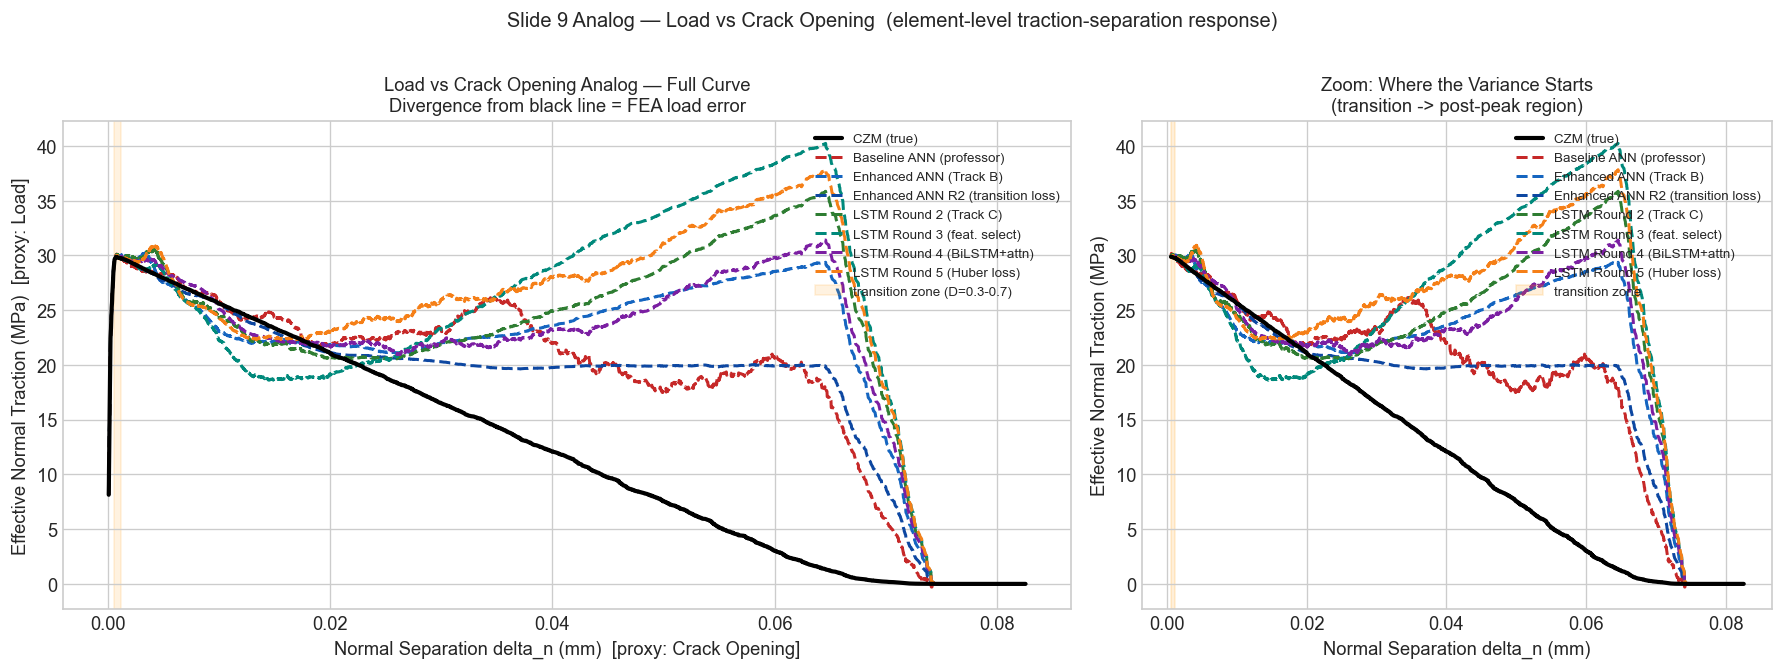


Peak traction vs CZM true (rolling mean):
  CZM (true) peak traction:  29.8571 MPa
  Baseline ANN (professor)               peak: 30.1199 MPa  (+0.9% overestimate)
  Enhanced ANN (Track B)                 peak: 30.2341 MPa  (+1.3% overestimate)
  Enhanced ANN R2 (transition loss)      peak: 29.9222 MPa  (+0.2% overestimate)
  LSTM Round 2 (Track C)                 peak: 35.8639 MPa  (+20.1% overestimate)
  LSTM Round 3 (feat. select)            peak: 40.2389 MPa  (+34.8% overestimate)
  LSTM Round 4 (BiLSTM+attn)             peak: 31.4140 MPa  (+5.2% overestimate)
  LSTM Round 5 (Huber loss)              peak: 37.8336 MPa  (+26.7% overestimate)


In [19]:
if not available:
    print('No models loaded — train at least one model first.')
else:
    # Unscale separN and tractN to physical units.
    # Feature order per timestep: failureIndex=0, modeMixity=1, separN=2,
    #   separT1=3, separT2=4, tractN=5, tractT1=6, tractT2=7
    # After temporal reversal in the pipeline, timestep index 19 = h0 (most recent).
    SEP_N_IDX  = 2
    TRAC_N_IDX = 5

    sep_n_phys  = X_test[:, 19, SEP_N_IDX]  * scaler_scale[SEP_N_IDX]  + scaler_mean[SEP_N_IDX]
    trac_n_phys = X_test[:, 19, TRAC_N_IDX] * scaler_scale[TRAC_N_IDX] + scaler_mean[TRAC_N_IDX]

    D_true = y_test
    eps = 1e-6  # guard against D_true = 1 (zero denominator)

    # Effective traction for each ML model:
    #   t_ML = t_true * (1 - D_pred) / (1 - D_true)
    # This is what Abaqus computes when the surrogate's D replaces the CZM's D.
    eff_trac = {'CZM (true)': trac_n_phys}
    for name in available:
        D_pred = preds[name]
        eff_trac[MODEL_LABELS[name]] = (
            trac_n_phys * (1.0 - D_pred) / np.maximum(1.0 - D_true, eps)
        )

    # Sort by separN ascending to mimic crack-opening progression
    sort_idx   = np.argsort(sep_n_phys)
    sep_sorted = sep_n_phys[sort_idx]
    WINDOW = 300   # rolling mean window

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                             gridspec_kw={'width_ratios': [1.6, 1]})

    # ── Left panel: full loading → peak → softening curve ────────────────────
    ax = axes[0]

    t_true_sorted = eff_trac['CZM (true)'][sort_idx]
    ax.plot(sep_sorted,
            pd.Series(t_true_sorted).rolling(WINDOW, center=True, min_periods=1).mean(),
            color='black', lw=2.5, label='CZM (true)', zorder=5)

    for name in available:
        label = MODEL_LABELS[name]
        t_ml = eff_trac[label][sort_idx]
        ax.plot(sep_sorted,
                pd.Series(t_ml).rolling(WINDOW, center=True, min_periods=1).mean(),
                color=MODEL_COLORS[name], lw=1.8, ls='--', label=label, zorder=4)

    # Shade the transition zone (D = 0.3-0.7) on the x-axis
    trans_mask = (D_true >= 0.3) & (D_true < 0.7)
    if trans_mask.sum() > 0:
        x0_trans = sep_n_phys[trans_mask].min()
        x1_trans = sep_n_phys[trans_mask].max()
        ax.axvspan(x0_trans, x1_trans, color='#FF9800', alpha=0.12, zorder=0,
                   label='transition zone (D=0.3-0.7)')

    ax.set_xlabel('Normal Separation delta_n (mm)  [proxy: Crack Opening]', fontsize=11)
    ax.set_ylabel('Effective Normal Traction (MPa)  [proxy: Load]', fontsize=11)
    ax.set_title('Load vs Crack Opening Analog — Full Curve\n'
                 'Divergence from black line = FEA load error', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')

    # ── Right panel: zoom into the divergence / variance region ──────────────
    ax2 = axes[1]

    # Zoom to where D > 0.1 (past the undamaged elastic region)
    div_mask = D_true > 0.1
    x_lo = np.percentile(sep_n_phys[div_mask], 5) if div_mask.sum() > 0 else sep_sorted[0]
    zoom_mask = sep_sorted >= x_lo

    sep_zoom      = sep_sorted[zoom_mask]
    t_true_zoom   = t_true_sorted[zoom_mask]

    ax2.plot(sep_zoom,
             pd.Series(t_true_zoom).rolling(WINDOW, center=True, min_periods=1).mean(),
             color='black', lw=2.5, label='CZM (true)', zorder=5)

    for name in available:
        label = MODEL_LABELS[name]
        t_ml_zoom = eff_trac[label][sort_idx][zoom_mask]
        ax2.plot(sep_zoom,
                 pd.Series(t_ml_zoom).rolling(WINDOW, center=True, min_periods=1).mean(),
                 color=MODEL_COLORS[name], lw=1.8, ls='--', label=label, zorder=4)

    if trans_mask.sum() > 0:
        ax2.axvspan(x0_trans, x1_trans, color='#FF9800', alpha=0.15, zorder=0,
                    label='transition zone')

    ax2.set_xlabel('Normal Separation delta_n (mm)', fontsize=11)
    ax2.set_ylabel('Effective Normal Traction (MPa)', fontsize=11)
    ax2.set_title('Zoom: Where the Variance Starts\n(transition -> post-peak region)', fontsize=11)
    ax2.legend(fontsize=8, loc='upper right')

    plt.suptitle('Slide 9 Analog — Load vs Crack Opening  '
                 '(element-level traction-separation response)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    # Quantify peak traction overestimation per model
    print('\nPeak traction vs CZM true (rolling mean):')
    t_true_smooth = pd.Series(t_true_sorted).rolling(
        WINDOW, center=True, min_periods=1).mean().values
    true_peak = t_true_smooth.max()
    print(f'  CZM (true) peak traction:  {true_peak:.4f} MPa')
    for name in available:
        label = MODEL_LABELS[name]
        t_ml_smooth = pd.Series(eff_trac[label][sort_idx]).rolling(
            WINDOW, center=True, min_periods=1).mean().values
        ml_peak = t_ml_smooth.max()
        pct = (ml_peak - true_peak) / abs(true_peak) * 100
        direction = 'overestimate' if pct > 0 else 'underestimate'
        print(f'  {label:<38} peak: {ml_peak:.4f} MPa  ({pct:+.1f}% {direction})')

In [20]:
rows = []
for name in available:
    y_pred = preds[name]
    val_mse = float(np.mean((y_pred - y_test)**2))
    mae_by_bin = stratified_mae(y_test, y_pred)
    rows.append({
        'Model':            MODEL_LABELS[name],
        'Test MSE':         f'{val_mse:.3e}',
        'vs professor':     f'{val_mse/PROFESSOR_VAL_MSE:.2f}×',
        'Initiation MAE':   f'{mae_by_bin["initiation"]:.5f}',
        'Transition MAE':   f'{mae_by_bin["transition"]:.5f}',
        'Post-peak MAE':    f'{mae_by_bin["post_peak"]:.5f}',
        'Failed MAE':       f'{mae_by_bin["failed"]:.5f}',
    })

# Add professor reference row
rows.insert(0, {
    'Model':          'Professor baseline (reported)',
    'Test MSE':       f'{PROFESSOR_VAL_MSE:.3e}',
    'vs professor':   '1.00×',
    'Initiation MAE': '—',
    'Transition MAE': '—  ← KEY METRIC',
    'Post-peak MAE':  '—',
    'Failed MAE':     '—',
})

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))
print()
print('KEY: Transition MAE drives FEA accuracy — lower is better.')
print('     Any model with "vs professor" < 1.00× outperforms the professor\'s baseline.')

                            Model  Test MSE vs professor Initiation MAE  Transition MAE Post-peak MAE Failed MAE
    Professor baseline (reported) 3.830e-05        1.00×              — —  ← KEY METRIC             —          —
         Baseline ANN (professor) 3.455e-05        0.90×        0.00290         0.00875       0.00518    0.00269
           Enhanced ANN (Track B) 3.636e-05        0.95×        0.00413         0.00837       0.00551    0.00283
Enhanced ANN R2 (transition loss) 2.059e-05        0.54×        0.00433         0.00684       0.00440    0.00151
           LSTM Round 2 (Track C) 5.261e-05        1.37×        0.00552         0.01022       0.00592    0.00373
      LSTM Round 3 (feat. select) 4.763e-05        1.24×        0.00576         0.00986       0.00457    0.00371
       LSTM Round 4 (BiLSTM+attn) 3.634e-05        0.95×        0.00518         0.00840       0.00491    0.00274
        LSTM Round 5 (Huber loss) 6.101e-05        1.59×        0.00734         0.01114       0.